# **EDA: Emergencysound (Kaggle)**

**Fuente:** https://www.kaggle.com/datasets/buraktaci/emergencysound

Dataset compuesto por **4.841 archivos WAV** con duración media aproximada de **1 segundo**, organizado en 4 clases orientadas a la detección de situaciones de emergencia. Es útil para sistemas de alerta temprana basados en el nivel y la intensidad del sonido.

- **Clases:** `Crying` | `High_intensity` | `Low_intensity` | `Violence`

## **1. Importaciones y configuración**

In [1]:
# Instalar la librería de Kaggle
%pip install kaggle

In [2]:
# Instalar dependencias
%pip install librosa soundfile tqdm seaborn scikit-learn -q

In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pathlib import Path
import zipfile

print('Librerías cargadas.')

Librerías cargadas.


In [4]:
# Estilo visual
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='Set2')

# Paleta de colores por clase
CLASS_COLORS = {
    'Crying': 'red',
    'High intensity': 'coral',
    'Low intensity': 'green',
    'Violence': 'purple'
}

print('Completado correctamente.')

Completado correctamente.


## **2. Carga y estructura del dataset**

> La estructura esperada es:
> ```
> emergencysound/
>   ├── Crying/
>   ├── High_intensity/
>   ├── Low_intensity/
>   └── Violence/
> ```

In [5]:
!mkdir -p ~/.kaggle
!echo KGAT_dd1fcb6b4d85ae0d06a9975911bcf359 > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
print("Configuración de Kaggle API completada.")

Configuración de Kaggle API completada.


In [6]:
# Descargar el dataset de Kaggle
DATASET_SLUG = 'buraktaci/emergencysound'
DOWNLOAD_PATH = './emergencysound'

!kaggle datasets download -d {DATASET_SLUG} -p {DOWNLOAD_PATH}

print(f"Dataset descargado a: {DOWNLOAD_PATH}")

Dataset URL: https://www.kaggle.com/datasets/buraktaci/emergencysound
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 391M/391M [00:04<00:00, 89.3MB/s]

Dataset descargado a: ./emergencysound


In [7]:
# Descomprimir el dataset
zip_file_path = os.path.join(DOWNLOAD_PATH, 'emergencysound.zip')
extract_to_path = DOWNLOAD_PATH # Extraer en el mismo directorio

print(f"Descomprimiendo {zip_file_path}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)
print(f"Dataset descomprimido en: {extract_to_path}")

# Eliminar el archivo zip para ahorrar espacio
os.remove(zip_file_path)
print("Archivo zip eliminado.")

Descomprimiendo ./emergencysound/emergencysound.zip...
Dataset descomprimido en: ./emergencysound
Archivo zip eliminado.


In [8]:
# Muestra los primeros 30 archivos/carpetas que encuentre recursivamente
base = Path('./emergencysound')
print("Estructura de directorios")
all_items = sorted(base.rglob('*'))
for item in all_items[:30]:
    print(item)

print(f"\nTotal de items encontrados: {len(all_items)}")
print(f"\nArchivos de audio")
wavs = list(base.rglob('*.wav'))
mp3s = list(base.rglob('*.mp3'))
print(f"WAV: {len(wavs)}")
print(f"MP3: {len(mp3s)}")
if wavs:
    print(f"\nEjemplo WAV: {wavs[0]}")
if mp3s:
    print(f"Ejemplo MP3: {mp3s[0]}")

Estructura de directorios
emergencysound/1sn
emergencysound/1sn/Crying
emergencysound/1sn/Crying/Crying (1).wav
emergencysound/1sn/Crying/Crying (10).wav
emergencysound/1sn/Crying/Crying (100).wav
emergencysound/1sn/Crying/Crying (101).wav
emergencysound/1sn/Crying/Crying (102).wav
emergencysound/1sn/Crying/Crying (103).wav
emergencysound/1sn/Crying/Crying (104).wav
emergencysound/1sn/Crying/Crying (105).wav
emergencysound/1sn/Crying/Crying (106).wav
emergencysound/1sn/Crying/Crying (107).wav
emergencysound/1sn/Crying/Crying (108).wav
emergencysound/1sn/Crying/Crying (109).wav
emergencysound/1sn/Crying/Crying (11).wav
emergencysound/1sn/Crying/Crying (110).wav
emergencysound/1sn/Crying/Crying (111).wav
emergencysound/1sn/Crying/Crying (112).wav
emergencysound/1sn/Crying/Crying (113).wav
emergencysound/1sn/Crying/Crying (114).wav
emergencysound/1sn/Crying/Crying (115).wav
emergencysound/1sn/Crying/Crying (116).wav
emergencysound/1sn/Crying/Crying (117).wav
emergencysound/1sn/Crying/Cryi

In [9]:
DATASET_PATH = Path('./emergencysound/1sn') # Apunta al directorio donde se descomprimió el zip

# Recopilación de archivos
records = []
for filepath in DATASET_PATH.rglob('*.wav'):
    label = filepath.parent.name
    records.append({'path': str(filepath), 'label': label, 'filename': filepath.name})

for filepath in DATASET_PATH.rglob('*.mp3'):
    label = filepath.parent.name
    records.append({'path': str(filepath), 'label': label, 'filename': filepath.name})

df = pd.DataFrame(records)
print(f'Total de archivos encontrados: {len(df)}')

Total de archivos encontrados: 4841


In [10]:
print([x.name for x in Path('./emergencysound/1sn').iterdir() if x.is_dir()])

['Crying', 'High intensity', 'Low intensity', 'Violence']


In [11]:
CLASSES = CLASSES = ['Crying', 'High intensity', 'Low intensity', 'Violence']

# Verificar la existencia de carpetas
for cls in CLASSES:
    path = os.path.join(DATASET_PATH, cls)
    exists = os.path.isdir(path)
    count = len(glob.glob(os.path.join(path, '*.wav'))) if exists else 0
    status = 'OK' if exists else 'NO'
    print(f'{status} | {cls:20s} --> {count:5d} archivos WAV')

print()
print('Si alguna carpeta muestra NO, revisa DATASET_PATH.')

OK | Crying               -->   636 archivos WAV
OK | High intensity       -->  2331 archivos WAV
OK | Low intensity        -->  1545 archivos WAV
OK | Violence             -->   329 archivos WAV

Si alguna carpeta muestra NO, revisa DATASET_PATH.


In [12]:
print(f"Shape: {df.shape}")

Shape: (4841, 3)


In [13]:
df.head(10)

,path,label,filename
0,emergencysound/1sn/Crying/Crying (501).wav,Crying,Crying (501).wav
1,emergencysound/1sn/Crying/Crying (117).wav,Crying,Crying (117).wav
2,emergencysound/1sn/Crying/Crying (83).wav,Crying,Crying (83).wav
3,emergencysound/1sn/Crying/Crying (599).wav,Crying,Crying (599).wav
4,emergencysound/1sn/Crying/Crying (285).wav,Crying,Crying (285).wav
5,emergencysound/1sn/Crying/Crying (200).wav,Crying,Crying (200).wav
6,emergencysound/1sn/Crying/Crying (622).wav,Crying,Crying (622).wav
7,emergencysound/1sn/Crying/Crying (568).wav,Crying,Crying (568).wav
8,emergencysound/1sn/Crying/Crying (226).wav,Crying,Crying (226).wav
9,emergencysound/1sn/Crying/Crying (87).wav,Crying,Crying (87).wav


In [14]:
df.tail(10)

,path,label,filename
4831,emergencysound/1sn/Violence/Violence (58).wav,Violence,Violence (58).wav
4832,emergencysound/1sn/Violence/Violence (155).wav,Violence,Violence (155).wav
4833,emergencysound/1sn/Violence/Violence (265).wav,Violence,Violence (265).wav
4834,emergencysound/1sn/Violence/Violence (76).wav,Violence,Violence (76).wav
4835,emergencysound/1sn/Violence/Violence (249).wav,Violence,Violence (249).wav
4836,emergencysound/1sn/Violence/Violence (132).wav,Violence,Violence (132).wav
4837,emergencysound/1sn/Violence/Violence (53).wav,Violence,Violence (53).wav
4838,emergencysound/1sn/Violence/Violence (212).wav,Violence,Violence (212).wav
4839,emergencysound/1sn/Violence/Violence (44).wav,Violence,Violence (44).wav
4840,emergencysound/1sn/Violence/Violence (318).wav,Violence,Violence (318).wav


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4841 entries, 0 to 4840
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   path      4841 non-null   object
 1   label     4841 non-null   object
 2   filename  4841 non-null   object
dtypes: object(3)
memory usage: 113.6+ KB


In [16]:
df.columns

Index(['path', 'label', 'filename'], dtype='object')

In [17]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
path,0
label,0
filename,0


In [18]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [19]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
path,0
label,0
filename,0


In [20]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
path,0.0
label,0.0
filename,0.0


In [21]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
path,object
label,object
filename,object


In [22]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['path', 'label', 'filename'], dtype='object')

## **3. Distribución de clases**


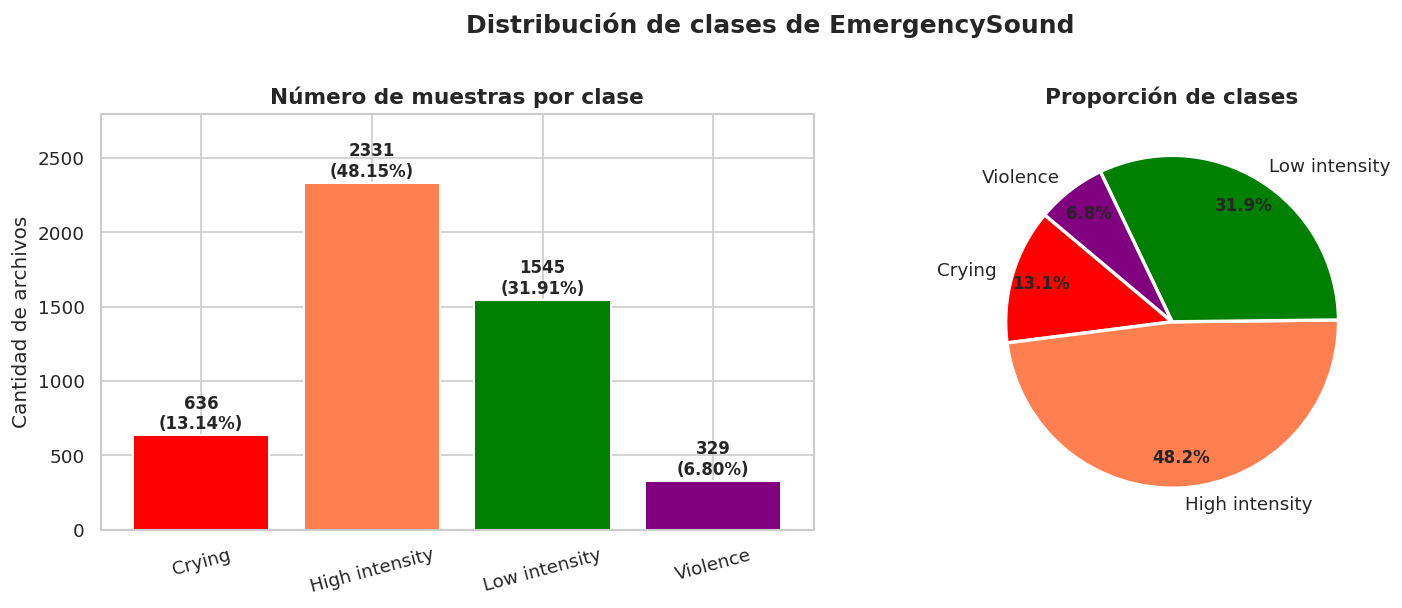


Ratio máx/mín: 7.09 --> Dataset DESBALANCEADO (considerar oversampling/weights.)


In [23]:
counts = df['label'].value_counts().reindex(CLASSES)
total = counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
colors = [CLASS_COLORS[c] for c in counts.index]
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val}\n({val/total*100:.2f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title('Número de muestras por clase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de archivos')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].tick_params(axis='x', rotation=15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
axes[1].set_title('Proporción de clases', fontsize=13, fontweight='bold')

plt.suptitle('Distribución de clases de EmergencySound', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Análisis de balance
ratio = counts.max() / counts.min()
print(f'\nRatio máx/mín: {ratio:.2f} --> ', end='')
print('Dataset BALANCEADO' if ratio < 1.5 else 'Dataset DESBALANCEADO (considerar oversampling/weights.)')

## **4. Análisis de la duración y el tamaño de los archivos**

In [24]:
# Extraer la duración de una muestra representativa (máx 200 por clase para más rapidez)
SAMPLE_N = 200
durations = []
sample_rates = []

for cls in CLASSES:
    subset = df[df['label'] == cls].sample(min(SAMPLE_N, len(df[df['label']==cls])), random_state=42)
    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f'Leyendo {cls}'):
        try:
            info = sf.info(row['path'])
            durations.append({'label': cls, 'duration_s': info.duration, 'sample_rate': info.samplerate})
            sample_rates.append(info.samplerate)
        except Exception:
            pass

df_dur = pd.DataFrame(durations)
print(f'\nSample rates únicos encontrados: {sorted(set(sample_rates))}')
print('\nEstadísticas de duración (segundos):')
print(df_dur.groupby('label')['duration_s'].describe().round(4))

Leyendo Violence: 100%|██████████| 200/200 [00:00<00:00, 935.78it/s]


Sample rates únicos encontrados: [44100, 48000]

Estadísticas de duración (segundos):
                count  mean  std  min  25%  50%  75%  max
label                                                    
Crying          200.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
High intensity  200.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
Low intensity   200.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0
Violence        200.0   1.0  0.0  1.0  1.0  1.0  1.0  1.0


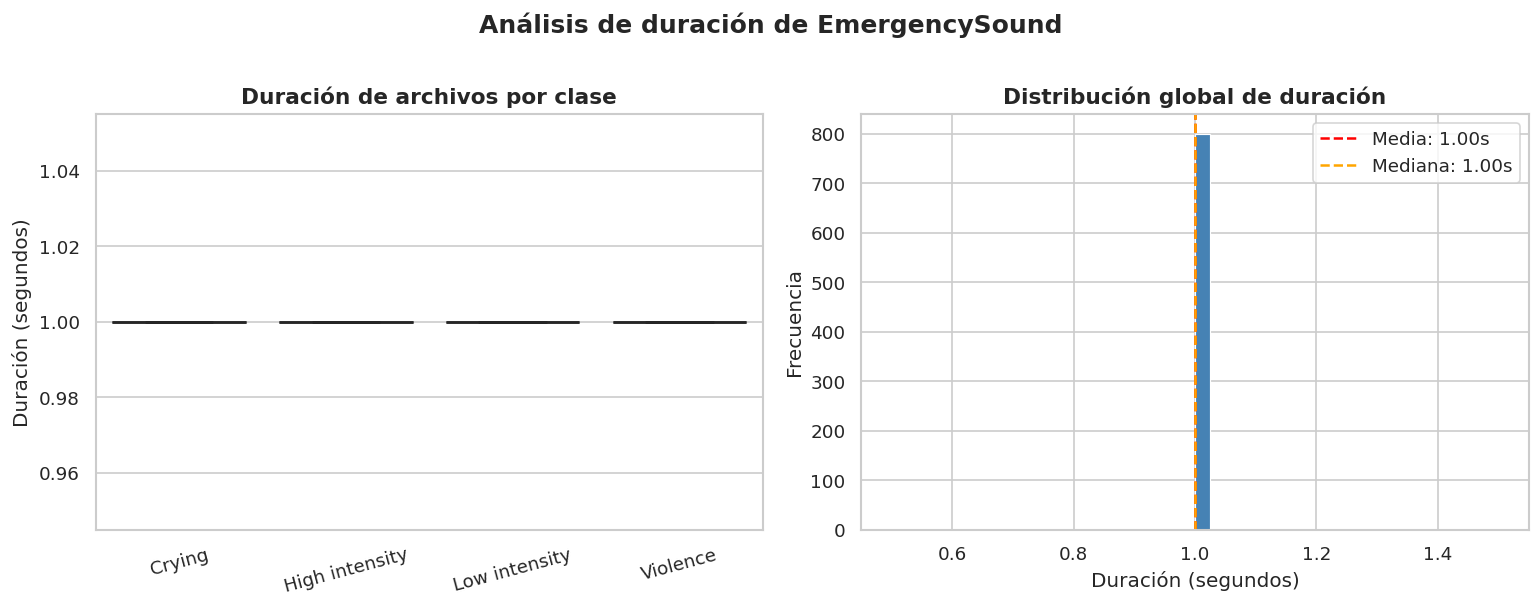

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot de duración
order = CLASSES
palette = [CLASS_COLORS[c] for c in order]
sns.boxplot(data=df_dur, x='label', y='duration_s', order=order,
            palette=palette, ax=axes[0], linewidth=1.5)
axes[0].set_title('Duración de archivos por clase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Duración (segundos)')
axes[0].tick_params(axis='x', rotation=15)

# Histograma de duración global
axes[1].hist(df_dur['duration_s'], bins=40, color='steelblue', edgecolor='white', linewidth=0.7)
axes[1].axvline(df_dur['duration_s'].mean(), color='red', linestyle='--', label=f'Media: {df_dur["duration_s"].mean():.2f}s')
axes[1].axvline(df_dur['duration_s'].median(), color='orange', linestyle='--', label=f'Mediana: {df_dur["duration_s"].median():.2f}s')
axes[1].set_title('Distribución global de duración', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Duración (segundos)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.suptitle('Análisis de duración de EmergencySound', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **5. Visualización de formas de onda**

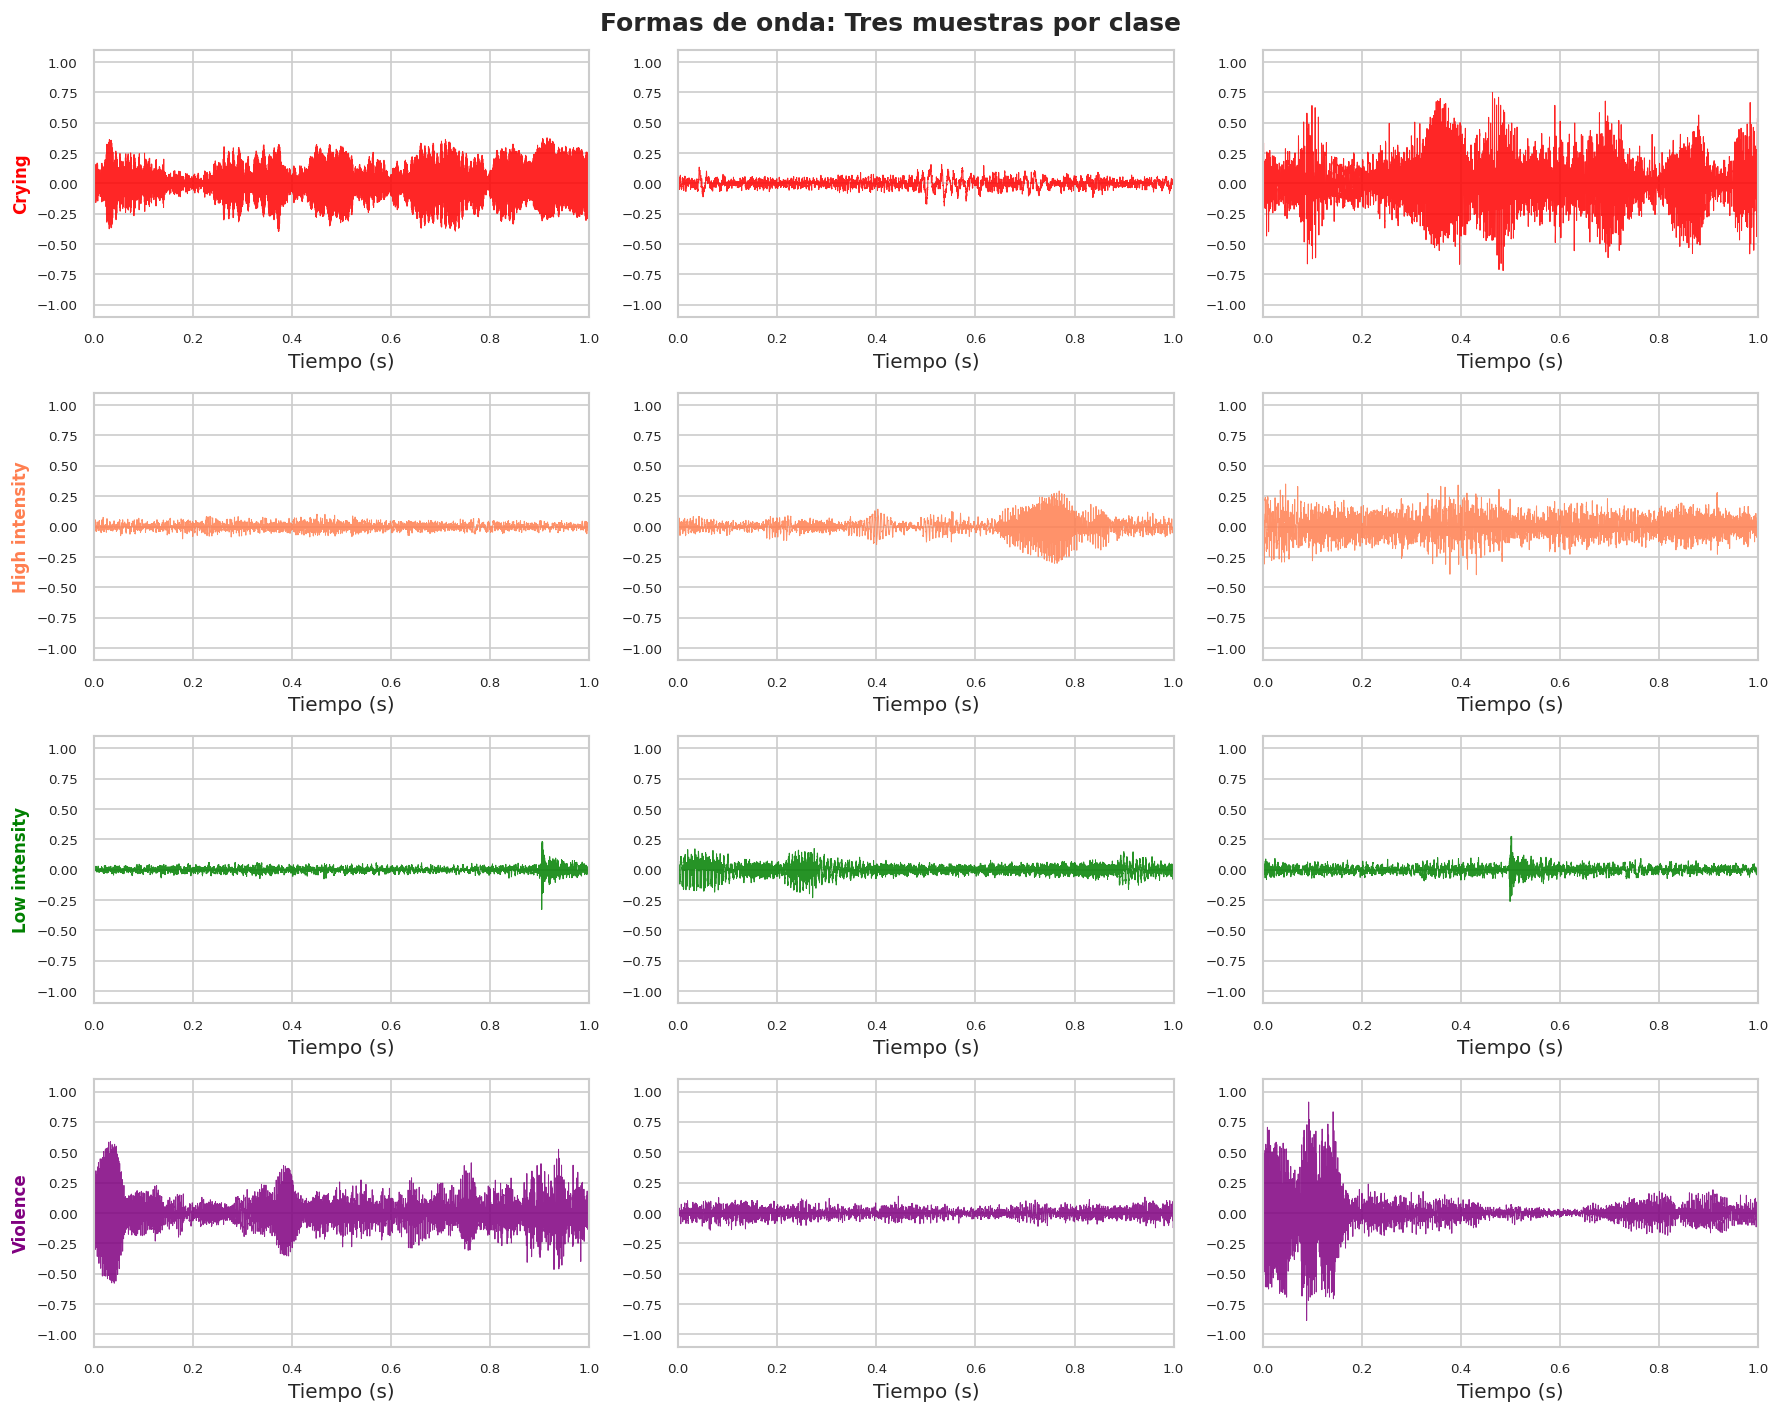

In [26]:
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
fig.suptitle('Formas de onda: Tres muestras por clase', fontsize=15, fontweight='bold')

for row_idx, cls in enumerate(CLASSES):
    samples = df[df['label'] == cls].sample(3, random_state=42)
    for col_idx, (_, record) in enumerate(samples.iterrows()):
        try:
            y, sr = librosa.load(record['path'], sr=None)
            t = np.linspace(0, len(y)/sr, len(y))
            ax = axes[row_idx][col_idx]
            ax.plot(t, y, color=CLASS_COLORS[cls], linewidth=0.6, alpha=0.85)
            ax.set_xlim([0, len(y)/sr])
            ax.set_ylim([-1.1, 1.1])
            if col_idx == 0:
                ax.set_ylabel(cls, fontsize=10, fontweight='bold', color=CLASS_COLORS[cls])
            ax.set_xlabel('Tiempo (s)')
            ax.tick_params(labelsize=8)
        except Exception as e:
            axes[row_idx][col_idx].text(0.5, 0.5, f'Error\n{repr(e)}', ha='center', va='center')

plt.tight_layout()
plt.show()

In [27]:
cls = 'High intensity'
print(repr(cls))
print(cls in CLASS_COLORS)
print(CLASS_COLORS)

'High intensity'
True
{'Crying': 'red', 'High intensity': 'coral', 'Low intensity': 'green', 'Violence': 'purple'}


## **6. Análisis espectral (FFT)**

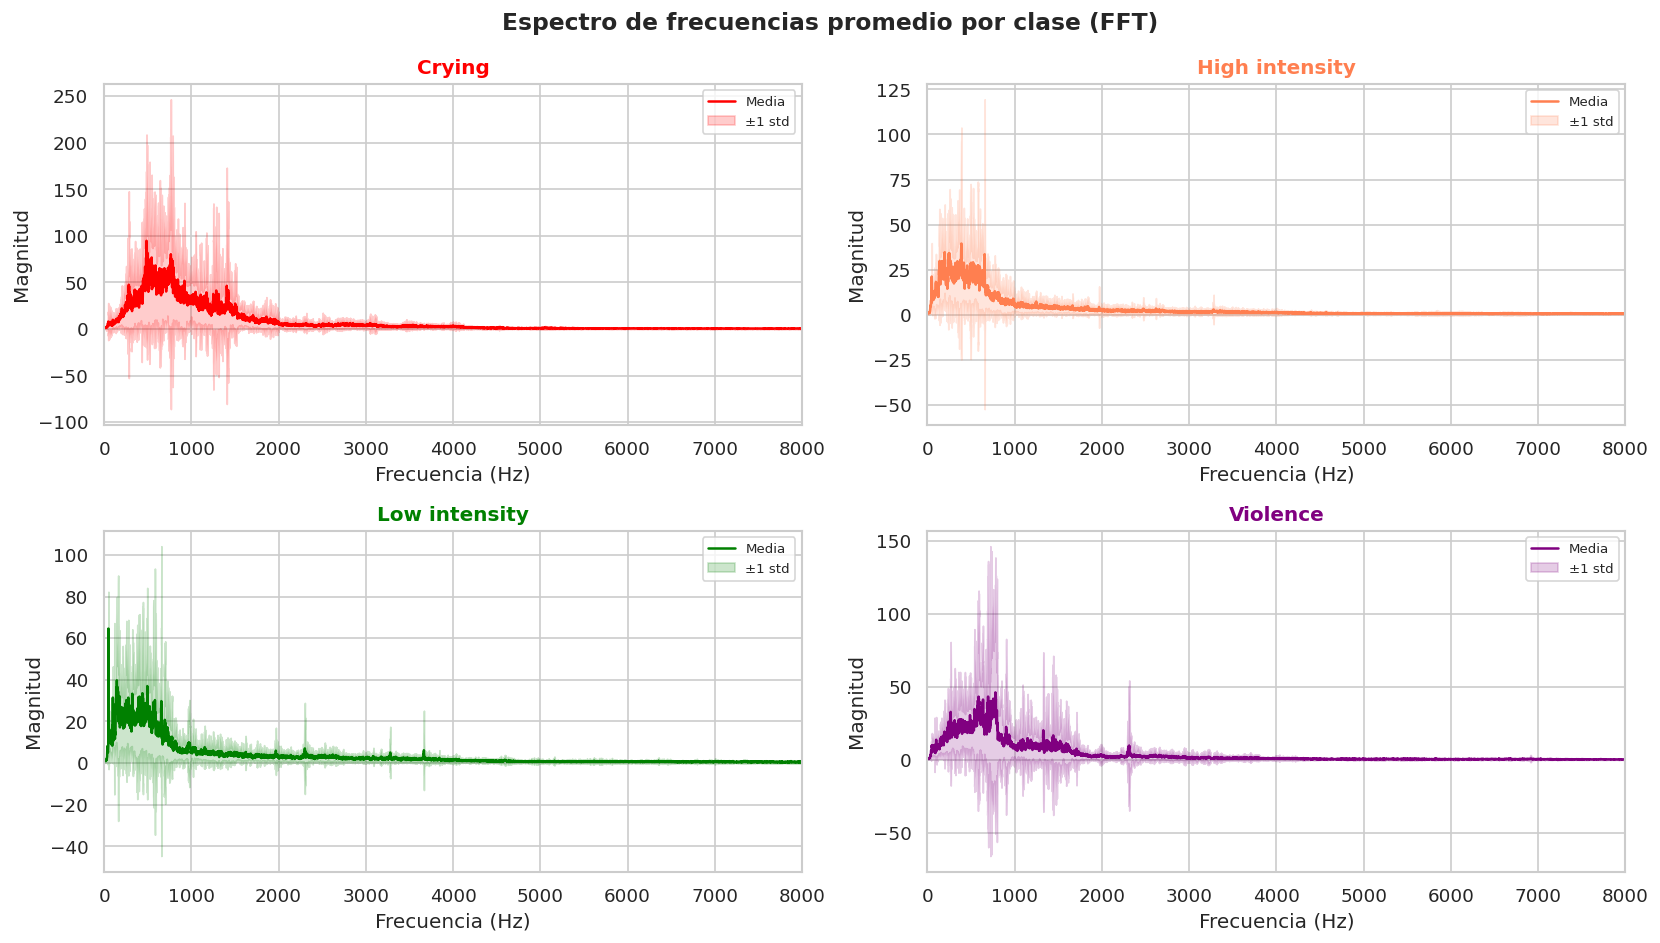

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Espectro de frecuencias promedio por clase (FFT)', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flatten(), CLASSES):
    subset = df[df['label'] == cls].sample(min(30, len(df[df['label']==cls])), random_state=42)
    spectra = []
    sr_ref = None
    for _, row in subset.iterrows():
        try:
            y, sr = librosa.load(row['path'], sr=22050, duration=1.0)
            sr_ref = sr
            fft_vals = np.abs(np.fft.rfft(y))
            spectra.append(fft_vals)
        except Exception:
            pass

    if spectra:
        min_len = min(len(s) for s in spectra)
        spectra = np.array([s[:min_len] for s in spectra])
        freqs = np.fft.rfftfreq(min_len * 2 - 1, d=1/sr_ref)[:min_len]
        mean_spec = np.mean(spectra, axis=0)
        std_spec = np.std(spectra, axis=0)

        ax.plot(freqs, mean_spec, color=CLASS_COLORS[cls], linewidth=1.5, label='Media')
        ax.fill_between(freqs, mean_spec - std_spec, mean_spec + std_spec,
                        color=CLASS_COLORS[cls], alpha=0.2, label='±1 std')
        ax.set_xlim([0, 8000])
        ax.set_title(cls, fontsize=12, fontweight='bold', color=CLASS_COLORS[cls])
        ax.set_xlabel('Frecuencia (Hz)')
        ax.set_ylabel('Magnitud')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## **7. Espectrogramas (Mel y STFT)**

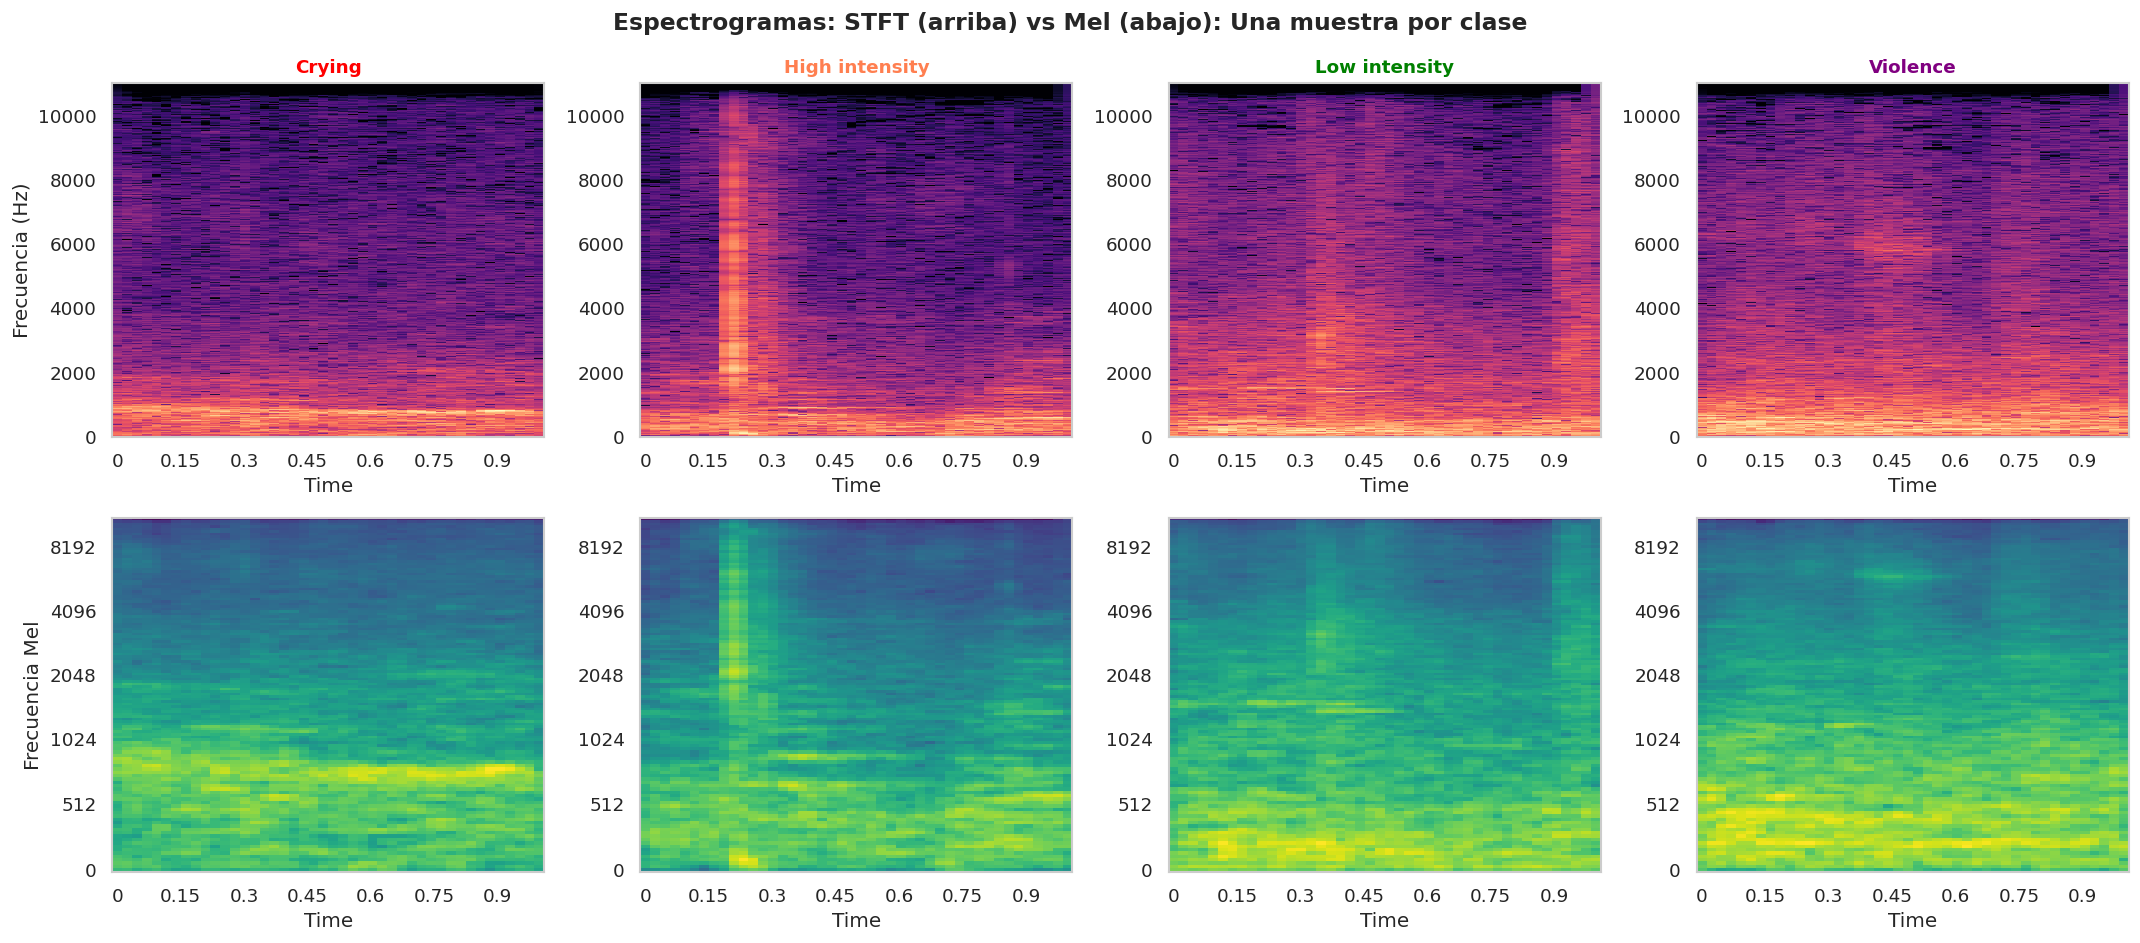

In [29]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Espectrogramas: STFT (arriba) vs Mel (abajo): Una muestra por clase', fontsize=14, fontweight='bold')

for col_idx, cls in enumerate(CLASSES):
    fpath = df[df['label'] == cls].sample(1, random_state=7).iloc[0]['path']
    try:
        y, sr = librosa.load(fpath, sr=22050, duration=1.5)

        # STFT
        D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
        librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[0][col_idx], cmap='magma')
        axes[0][col_idx].set_title(cls, fontsize=11, fontweight='bold', color=CLASS_COLORS[cls])
        axes[0][col_idx].set_ylabel('Frecuencia (Hz)' if col_idx == 0 else '')

        # Mel
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1][col_idx], cmap='viridis')
        axes[1][col_idx].set_ylabel('Frecuencia Mel' if col_idx == 0 else '')

    except Exception as e:
        axes[0][col_idx].text(0.5, 0.5, str(e), ha='center', va='center', fontsize=8)
        axes[1][col_idx].text(0.5, 0.5, str(e), ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## **8. Extracción y análisis de características acústicas**

Características extraídas:
- **MFCCs (1-13):** coeficientes mel-frecuency cepstrales
- **ZCR:** zero-crossing rate (sonidos periódicos vs. ruido)
- **RMS energy:** energía media cuadrada
- **Spectral centroid:** "centro de masa" del espectro
- **Spectral bandwidth**
- **Spectral rolloff**
- **Chroma features (1-12)**

In [30]:
def extract_features(fpath, sr_target=22050, duration=1.0):
    """Extrae vector de características acústicas de un archivo WAV."""
    y, sr = librosa.load(fpath, sr=sr_target, duration=duration)
    if len(y) == 0:
        return None

    feats = {}

    # MFCCs (13 coeficientes, media y std)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i, (m, s) in enumerate(zip(mfccs.mean(axis=1), mfccs.std(axis=1))):
        feats[f'mfcc_{i+1}_mean'] = m
        feats[f'mfcc_{i+1}_std'] = s

    # ZCR
    zcr = librosa.feature.zero_crossing_rate(y)
    feats['zcr_mean'] = zcr.mean()
    feats['zcr_std'] = zcr.std()

    # RMS energy
    rms = librosa.feature.rms(y=y)
    feats['rms_mean'] = rms.mean()
    feats['rms_std'] = rms.std()

    # Spectral centroid
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)
    feats['spectral_centroid_mean'] = sc.mean()
    feats['spectral_centroid_std'] = sc.std()

    # Spectral bandwidth
    sb = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    feats['spectral_bandwidth_mean'] = sb.mean()
    feats['spectral_bandwidth_std'] = sb.std()

    # Spectral rolloff
    sro = librosa.feature.spectral_rolloff(y=y, sr=sr)
    feats['spectral_rolloff_mean'] = sro.mean()
    feats['spectral_rolloff_std'] = sro.std()

    # Chroma (12 notas)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i, (m, s) in enumerate(zip(chroma.mean(axis=1), chroma.std(axis=1))):
        feats[f'chroma_{i+1}_mean'] = m
        feats[f'chroma_{i+1}_std'] = s

    return feats

print('Función de extracción de características lista.')

Función de extracción de características lista.


In [31]:
# Este bloque puede tardar varios minutos con el dataset completo.
# Ajustar MAX_PER_CLASS para acelerar durante la exploración.
MAX_PER_CLASS = 300  # hay que poner None para usarlos todos

feature_records = []
errors = 0

for cls in CLASSES:
    subset = df[df['label'] == cls]
    if MAX_PER_CLASS:
        subset = subset.sample(min(MAX_PER_CLASS, len(subset)), random_state=42)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f'Extrayendo {cls}'):
        try:
            feats = extract_features(row['path'])
            if feats:
                feats['label'] = cls
                feature_records.append(feats)
        except Exception:
            errors += 1

df_feats = pd.DataFrame(feature_records)
print(f'\nTotal de muestras con características: {len(df_feats)}')
print(f'Errores de carga: {errors}')
print(f'Número de características: {df_feats.shape[1] - 1}') # -1 por label
df_feats.head()

Extrayendo Violence: 100%|██████████| 300/300 [00:09<00:00, 31.87it/s]


Total de muestras con características: 1200
Errores de carga: 0
Número de características: 60


,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_3_mean,mfcc_3_std,mfcc_4_mean,mfcc_4_std,mfcc_5_mean,mfcc_5_std,...,chroma_8_std,chroma_9_mean,chroma_9_std,chroma_10_mean,chroma_10_std,chroma_11_mean,chroma_11_std,chroma_12_mean,chroma_12_std,label
0,-254.798981,22.586605,72.750999,20.279375,-111.471222,10.445190,-16.701500,13.097507,-15.411424,12.190384,...,0.023262,0.008705,0.017123,0.005536,0.009818,0.012057,0.022278,0.022800,0.041976,Crying
1,-242.694183,16.672022,127.832108,7.947952,12.895011,6.916907,20.306061,7.143901,-2.644404,5.197734,...,0.180075,0.506968,0.349658,0.327482,0.212734,0.346007,0.265954,0.458764,0.298148,Crying
2,-142.463181,22.461292,145.888123,30.693609,-18.657709,21.352102,-3.247532,11.701500,-26.297640,11.103608,...,0.315928,0.206549,0.265724,0.214588,0.246912,0.314558,0.318986,0.369508,0.362200,Crying
3,-254.339737,9.492127,147.152008,9.096617,-38.789478,7.979650,-0.332593,4.857774,-12.464759,4.763162,...,0.054082,0.055780,0.038608,0.074456,0.050330,0.067164,0.044002,0.093144,0.096663,Crying
4,-106.164696,21.051722,142.329773,14.449821,-54.169888,20.940372,-17.631910,17.454586,-23.308094,11.155900,...,0.353840,0.250635,0.197044,0.138519,0.172111,0.292886,0.311069,0.224743,0.262254,Crying


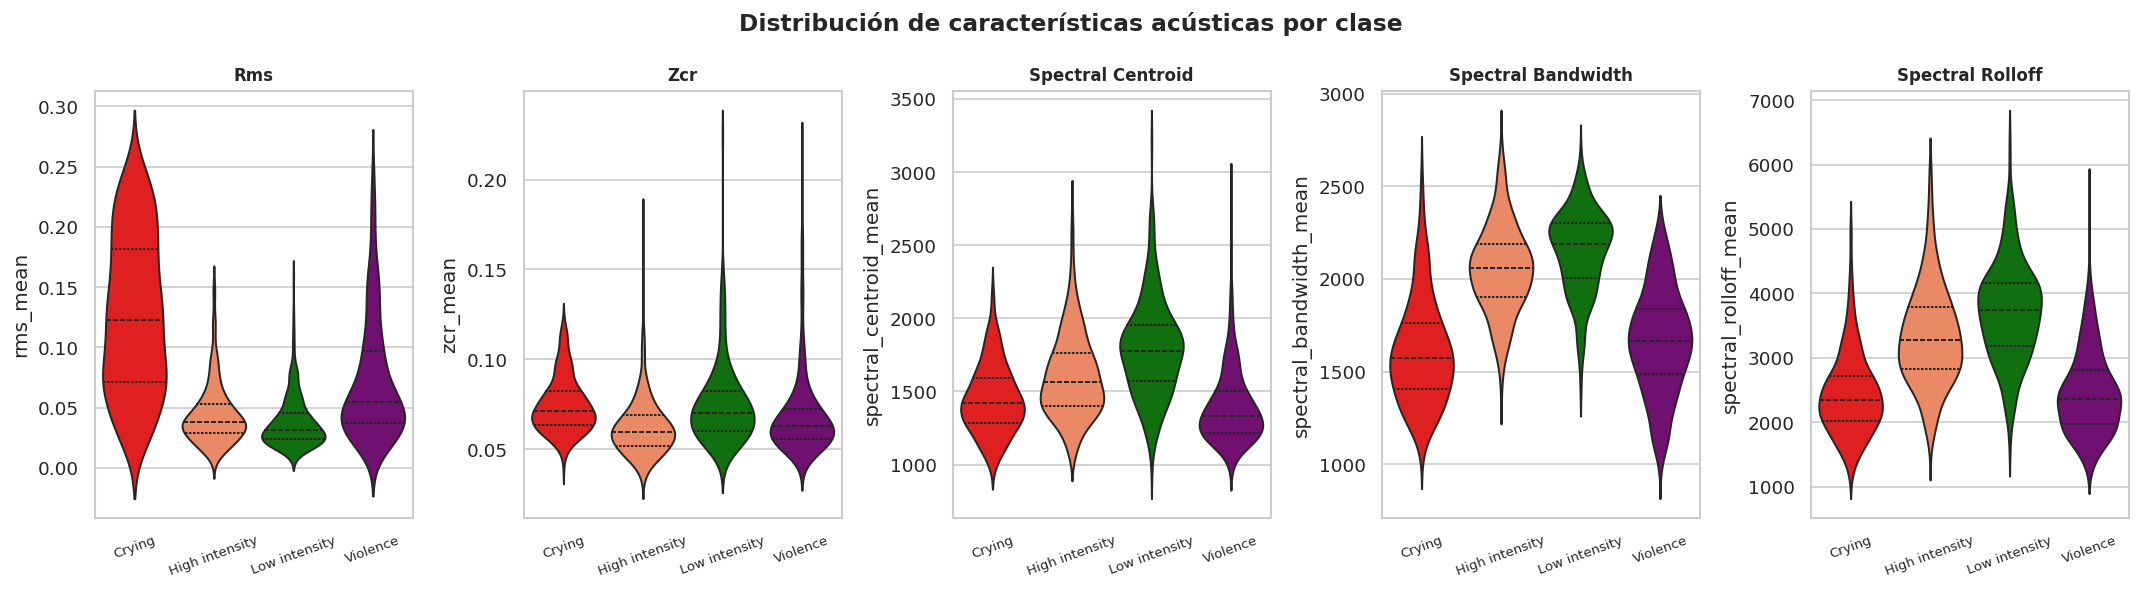

In [32]:
# Características clave (medias)
key_feats = ['rms_mean', 'zcr_mean', 'spectral_centroid_mean',
             'spectral_bandwidth_mean', 'spectral_rolloff_mean']

fig, axes = plt.subplots(1, len(key_feats), figsize=(18, 5))
fig.suptitle('Distribución de características acústicas por clase', fontsize=14, fontweight='bold')

for ax, feat in zip(axes, key_feats):
    sns.violinplot(data=df_feats, x='label', y=feat, palette=CLASS_COLORS,
                   order=CLASSES, ax=ax, inner='quartile', linewidth=1.2)
    ax.set_title(feat.replace('_mean','').replace('_',' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20, labelsize=8)

plt.tight_layout()
plt.show()

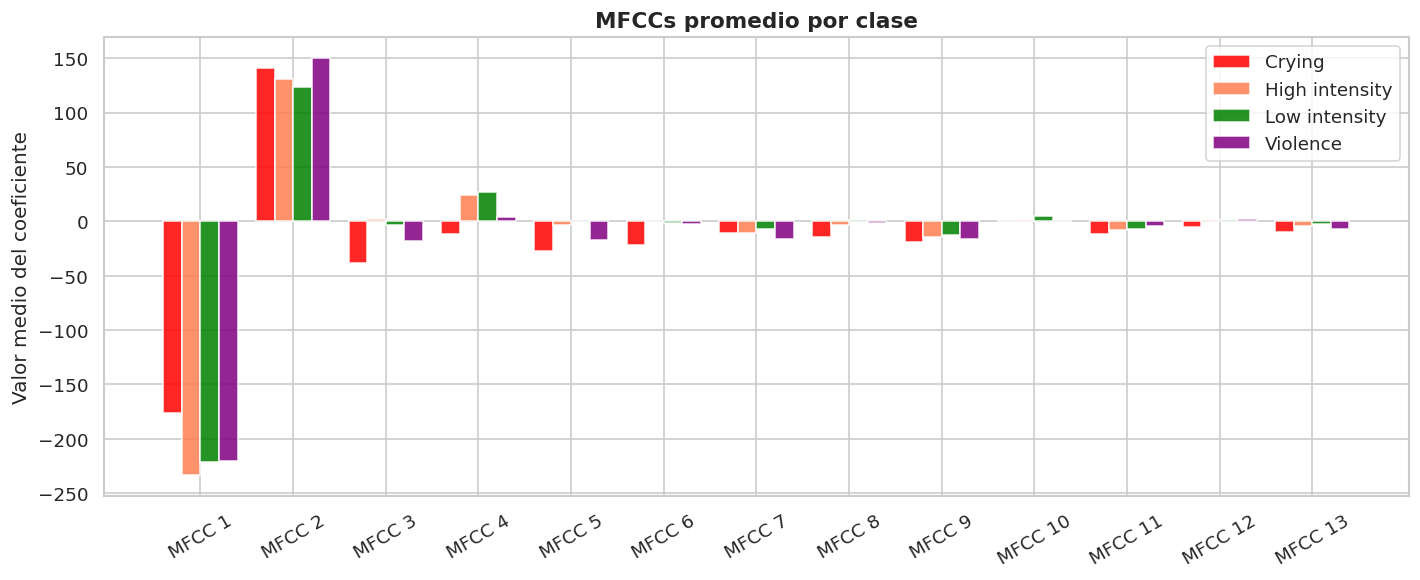

In [33]:
# MFCCs promedio por clase
mfcc_cols = [f'mfcc_{i}_mean' for i in range(1, 14)]
mfcc_by_class = df_feats.groupby('label')[mfcc_cols].mean()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(13)
width = 0.2
for i, cls in enumerate(CLASSES):
    ax.bar(x + i*width, mfcc_by_class.loc[cls].values, width,
           label=cls, color=CLASS_COLORS[cls], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width*1.5)
ax.set_xticklabels([f'MFCC {i}' for i in range(1, 14)], rotation=30)
ax.set_title('MFCCs promedio por clase', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor medio del coeficiente')
ax.legend()

plt.tight_layout()
plt.show()

## **9. Matriz de correlación entre características**

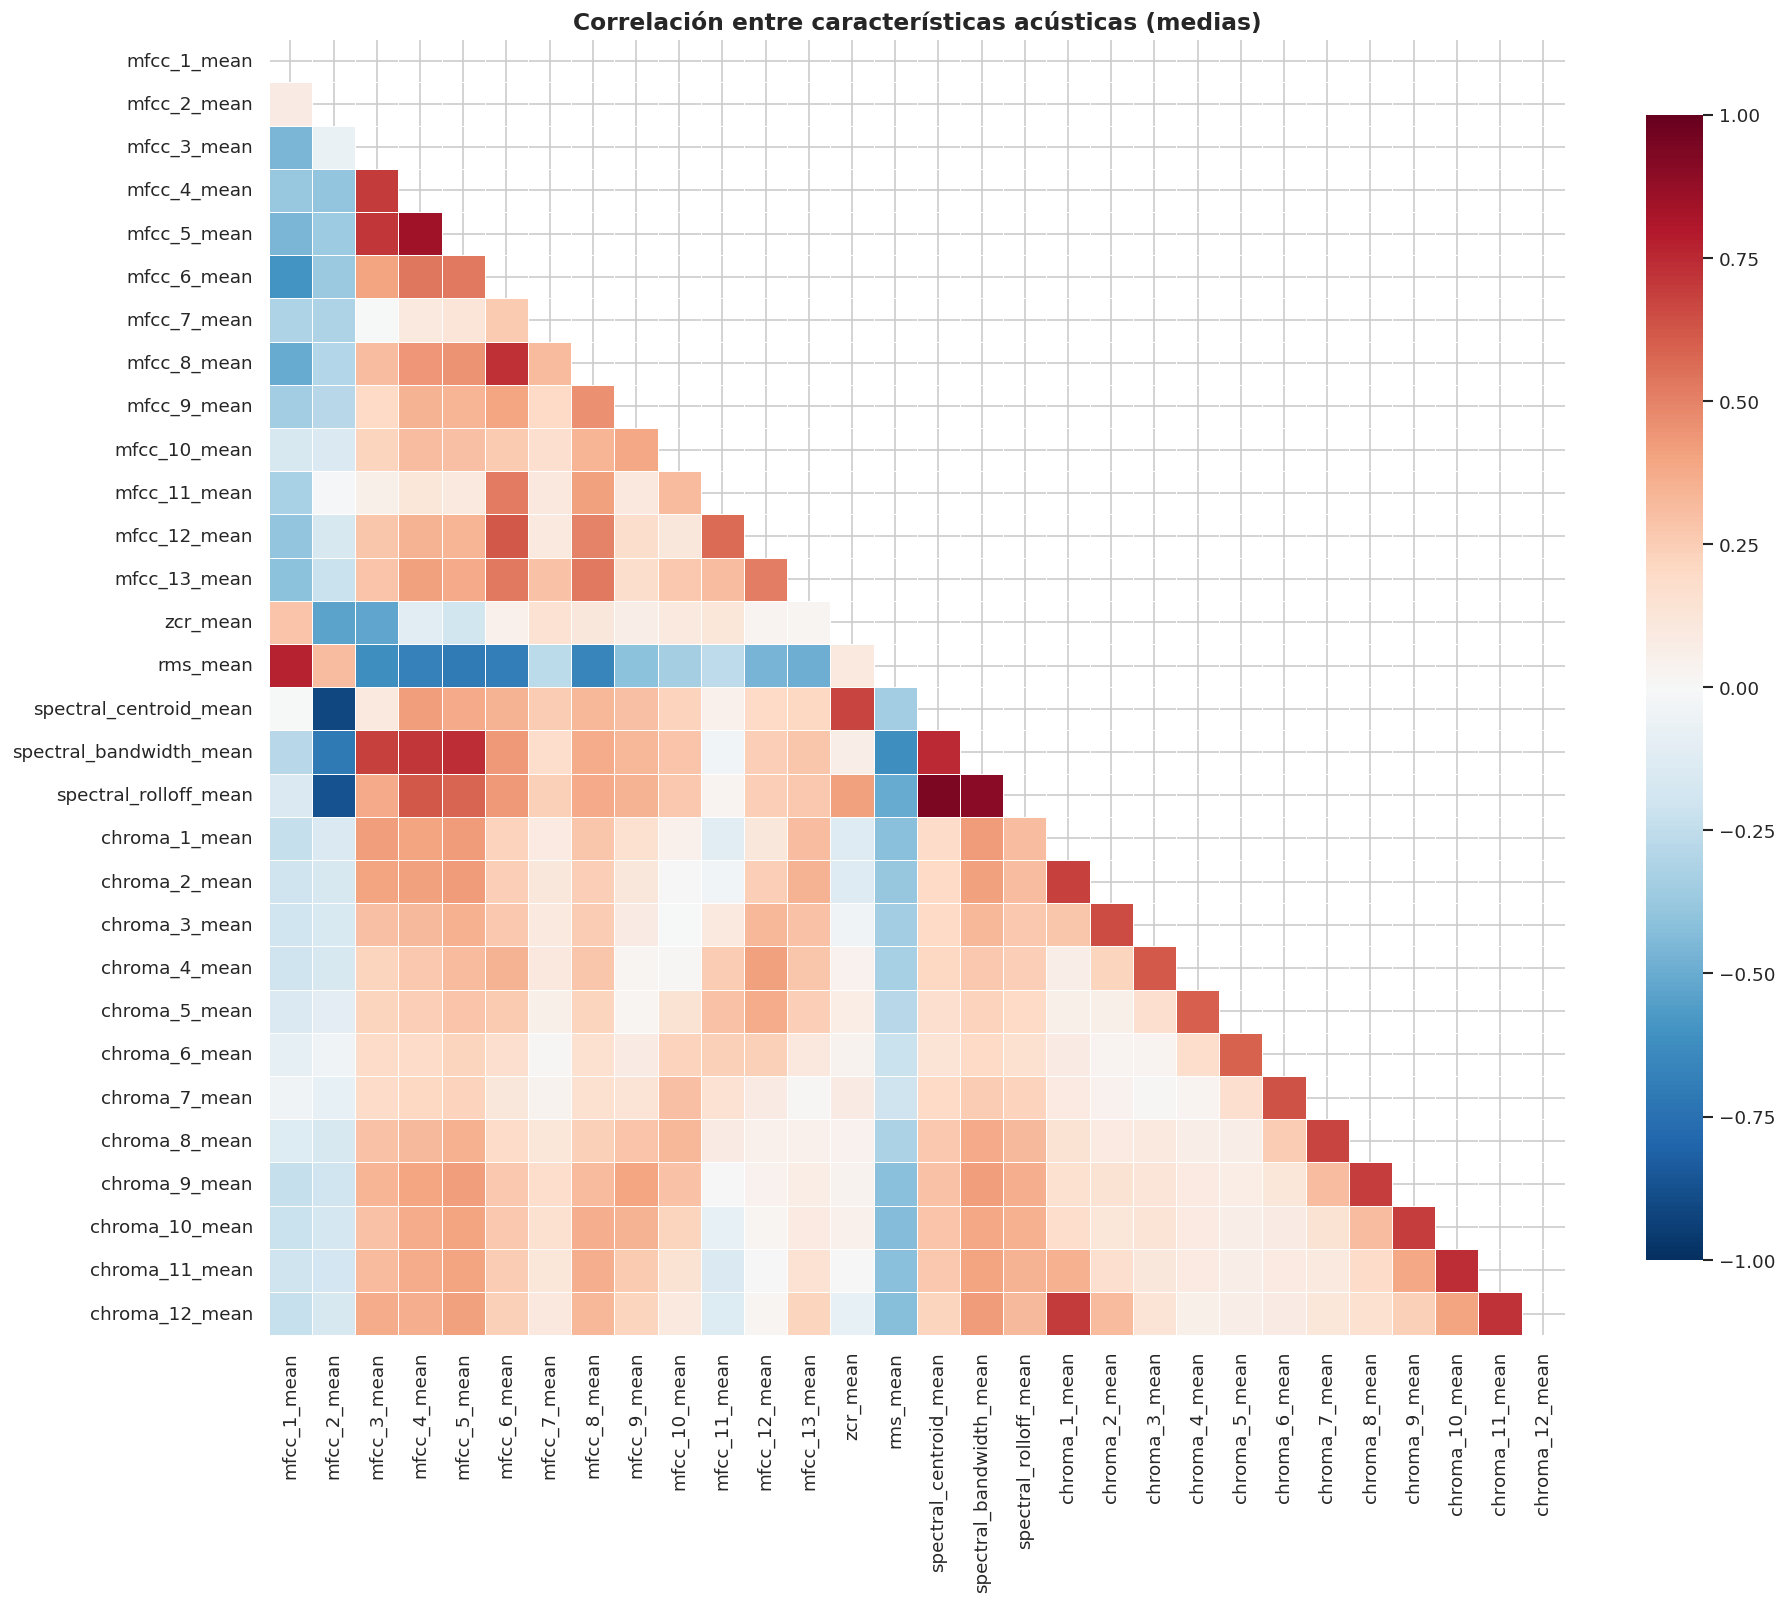

Top 10 pares más correlacionados:
spectral_rolloff_mean    spectral_centroid_mean     0.938023
spectral_centroid_mean   mfcc_2_mean                0.913434
spectral_rolloff_mean    spectral_bandwidth_mean    0.903157
                         mfcc_2_mean                0.872644
mfcc_5_mean              mfcc_4_mean                0.847829
rms_mean                 mfcc_1_mean                0.772653
spectral_bandwidth_mean  spectral_centroid_mean     0.748865
                         mfcc_5_mean                0.739359
chroma_11_mean           chroma_10_mean             0.738804
mfcc_8_mean              mfcc_6_mean                0.729905


In [34]:
# Usar solo las medias para la correlación (menos ruidoso)
mean_cols = [c for c in df_feats.columns if c.endswith('_mean')]
corr = df_feats[mean_cols].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3,
            annot=False, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlación entre características acústicas (medias)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlaciones absolutas
corr_pairs = (corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
                   .stack()
                   .abs()
                   .sort_values(ascending=False))
print('Top 10 pares más correlacionados:')
print(corr_pairs.head(10).to_string())

## **10. Reducción de dimensionalidad: PCA y t-SNE**

In [35]:
X = df_feats[mean_cols].values
y_labels = df_feats['label'].values

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

# t-SNE (sobre los primeros 20 PCs para eficiencia)
pca50 = PCA(n_components=min(20, X_scaled.shape[1]), random_state=42)
X_pca50 = pca50.fit_transform(X_scaled)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_pca50)

print(f'PCA - varianza explicada por PC1: {var_explained[0]*100:.2f} %, PC2: {var_explained[1]*100:.2f} %')

PCA - varianza explicada por PC1: 31.35 %, PC2: 10.22 %


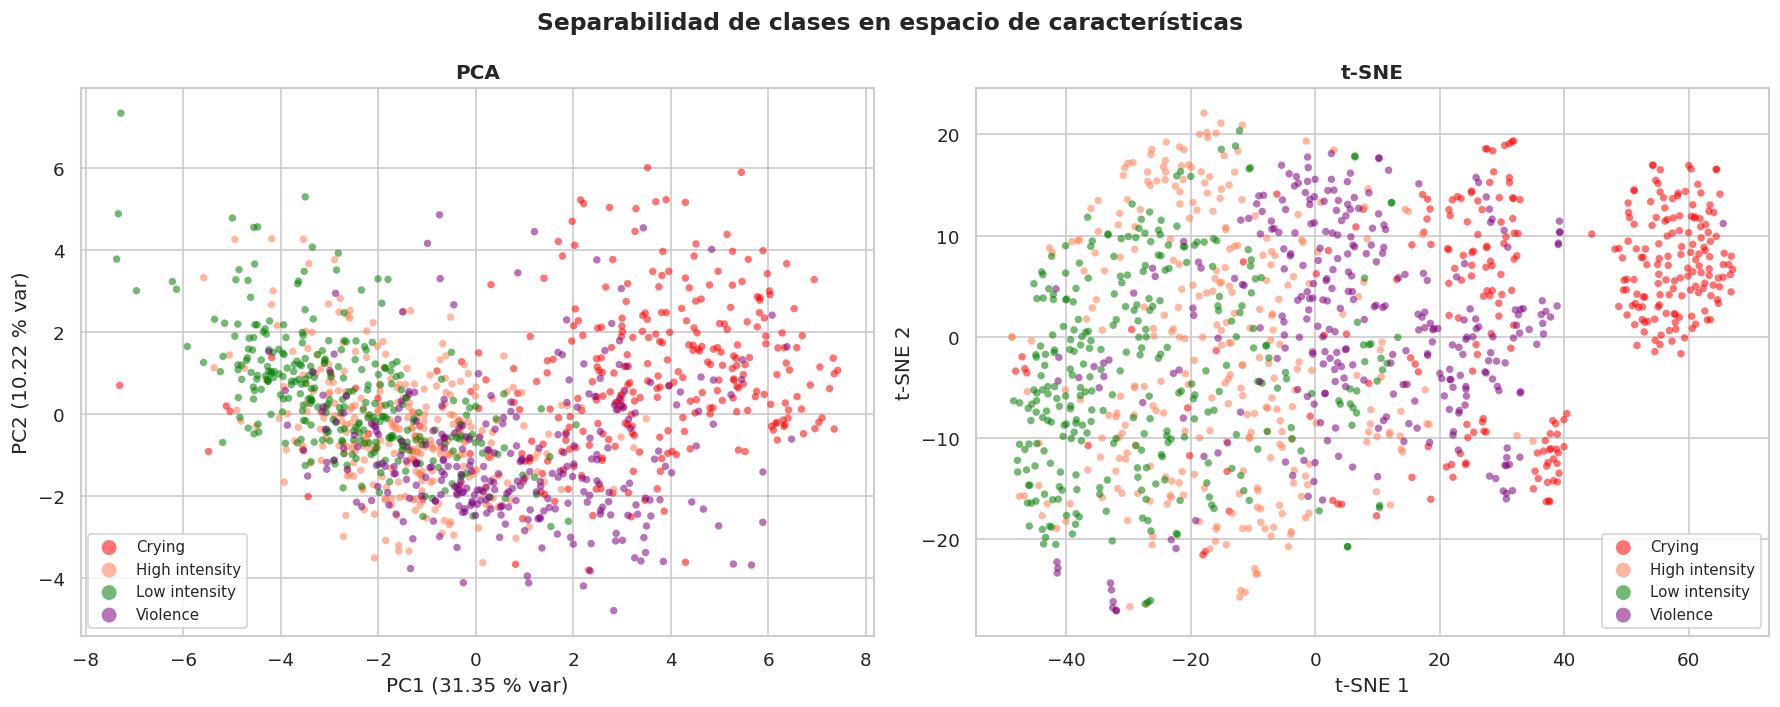

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Separabilidad de clases en espacio de características', fontsize=14, fontweight='bold')

for ax, X_2d, title, xlabel, ylabel in [
    (axes[0], X_pca, 'PCA', f'PC1 ({var_explained[0]*100:.2f} % var)', f'PC2 ({var_explained[1]*100:.2f} % var)'),
    (axes[1], X_tsne, 't-SNE', 't-SNE 1', 't-SNE 2')
]:
    for cls in CLASSES:
        mask = y_labels == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=CLASS_COLORS[cls], label=cls, alpha=0.55, s=20, edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
plt.show()

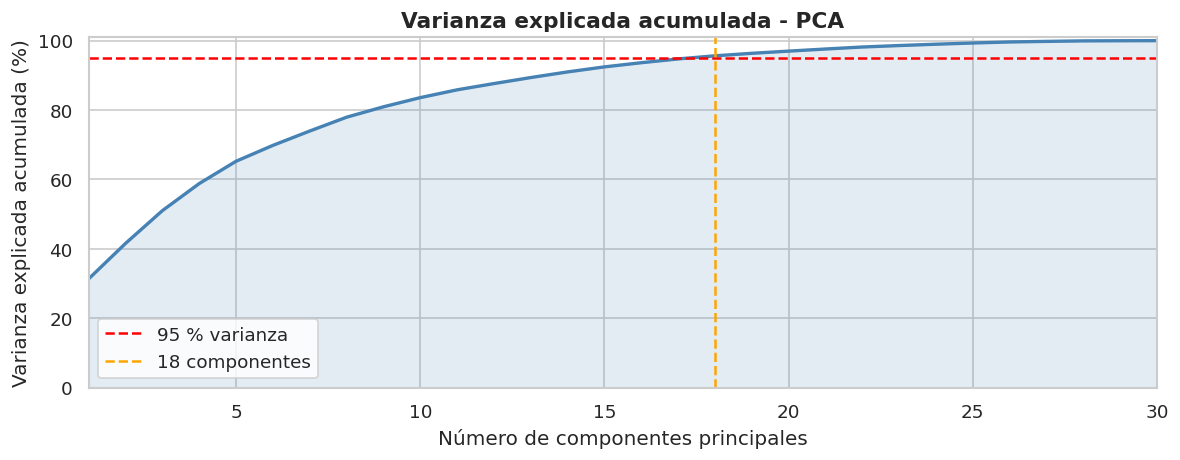


 --> Se necesitan 18 componentes para explicar el 95 % de la varianza.


In [37]:
# Varianza explicada acumulada PCA
pca_full = PCA(random_state=42).fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cum_var >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cum_var)+1), cum_var*100, color='steelblue', linewidth=2)
ax.axhline(95, color='red', linestyle='--', label='95 % varianza')
ax.axvline(n_95, color='orange', linestyle='--', label=f'{n_95} componentes')
ax.fill_between(range(1, len(cum_var)+1), 0, cum_var*100, alpha=0.15, color='steelblue')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza explicada acumulada (%)')
ax.set_title('Varianza explicada acumulada - PCA', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim([1, min(50, len(cum_var))])
ax.set_ylim([0, 101])

plt.tight_layout()
plt.show()

print(f'\n --> Se necesitan {n_95} componentes para explicar el 95 % de la varianza.')

## **11. Conclusiones**

In [38]:
print('=' * 60)
print('RESUMEN EDA: EmergencySound')
print('=' * 60)

print(f'\nTotal de archivos: {len(df)}')
print(f'Clases: {len(CLASSES)} ({", ".join(CLASSES)})')

counts = df['label'].value_counts()
ratio = counts.max() / counts.min()
print(f'Balance (ratio máx/mín): {ratio:.2f}', end='  ')
print('Balanceado' if ratio < 1.5 else 'Desbalanceado')

print(f'\nDuración media: {df_dur["duration_s"].mean():.2f} s')
print(f'Duración mediana: {df_dur["duration_s"].median():.2f} s')
print(f'Rango: {df_dur["duration_s"].min():.2f} – {df_dur["duration_s"].max():.2f} s')
print(f'Sample rates: {sorted(set(sample_rates))}')

print(f'\nCaracterísticas extraídas: {len(mean_cols)} (medias)')
print(f'PCA 95 % varianza: {n_95} componentes')
print('=' * 60)

RESUMEN EDA: EmergencySound

Total de archivos: 4841
Clases: 4 (Crying, High intensity, Low intensity, Violence)
Balance (ratio máx/mín): 7.09  Desbalanceado

Duración media: 1.00 s
Duración mediana: 1.00 s
Rango: 1.00 – 1.00 s
Sample rates: [44100, 48000]

Características extraídas: 30 (medias)
PCA 95 % varianza: 18 componentes
